### Load in Data Sets and Merge them together

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns

# Load dataset
netflix = pd.read_csv("C:\\Users\\aj4ho\\my-final-project\\data\\netflix_titles.csv")
imdb = pd.read_csv("C:\\Users\\aj4ho\\my-final-project\\data\\imdb_data.csv")

# extract title and year from imdb dataset
def split_name(x):
    match = re.match(r'(.+)\n\((\d{4})\)', str(x))
    if match:
        return pd.Series([match.group(1), int(match.group(2))])
    return pd.Series([x, None])

imdb[['title','release_year']] = imdb['Name'].apply(split_name)

# keep only needed columns
imdb = imdb[['title','release_year','Rating']]

# clean titles
netflix['title_clean'] = netflix['title'].str.strip()
imdb['title_clean'] = imdb['title'].str.strip()

# merge datasets
df = pd.merge(
    netflix,
    imdb,
    left_on=['title_clean','release_year'],
    right_on=['title_clean','release_year'],
    how='left'
)

df.head()
# View first rows

,show_id,type,title_x,director,cast,country,date_added,release_year,rating,duration,listed_in,description,title_clean,title_y,Rating
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Dick Johnson Is Dead,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Blood & Water,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Ganglands,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Jailbirds New Orleans,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Kota Factory,NaN,NaN


### Basic Statistics

In [114]:
# number of observations and features
print("Dataset shape:", df.shape)

# data types
print("\nData Types:\n")
print(df.dtypes)

# summary statistics
df.describe(include="all")

Dataset shape: (8860, 15)

Data Types:

show_id             str
type                str
title_x             str
director            str
cast                str
country             str
date_added          str
release_year      int64
rating              str
duration            str
listed_in           str
description         str
title_clean         str
title_y             str
Rating          float64
dtype: object


,show_id,type,title_x,director,cast,country,date_added,release_year,rating,duration,listed_in,description,title_clean,title_y,Rating
count,8860,8860,8860,6226,8032,8029,8850,8860.000000,8856,8857,8860,8860,8860,1892,1892.000000
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775,8806,1839,NaN
top,s7231,Movie,Krish Trish and Baltiboy: Face Your Fears,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,"In three tales about fear, a baby elephant get...",Krish Trish and Baltiboy: Face Your Fears,Krish Trish and Baltiboy: Face Your Fears\r,NaN
freq,8,6184,8,19,19,2832,113,NaN,3223,1793,362,8,8,8,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.179007,NaN,NaN,NaN,NaN,NaN,NaN,6.233140
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.810635,NaN,NaN,NaN,NaN,NaN,NaN,1.157395
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,6.400000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN,NaN,NaN,7.100000


### Distribution of Target Variable (rating)

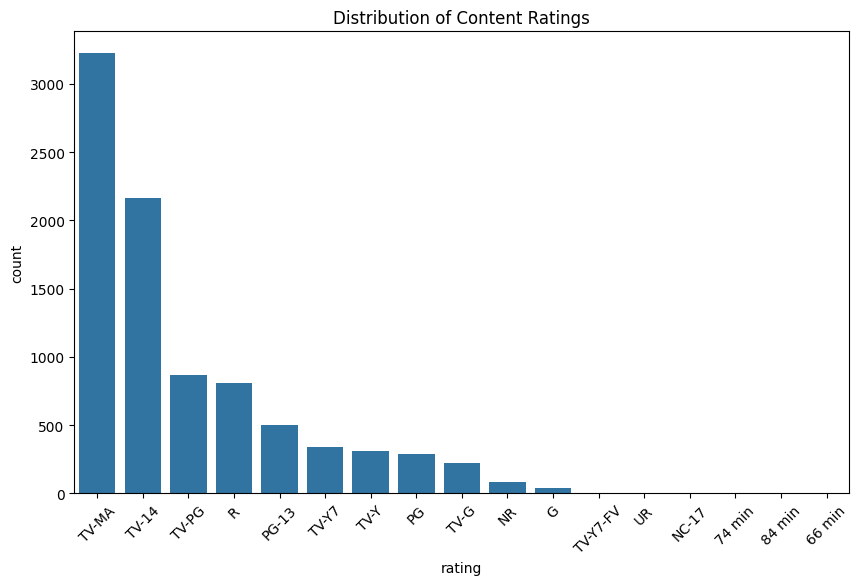

In [115]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="rating", order=df["rating"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution of Content Ratings")
plt.show()

### Missing Value Analysis

In [116]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

title_y         6968
Rating          6968
director        2634
country          831
cast             828
date_added        10
rating             4
duration           3
type               0
title_x            0
show_id            0
listed_in          0
release_year       0
title_clean        0
description        0
dtype: int64


### Visualizations

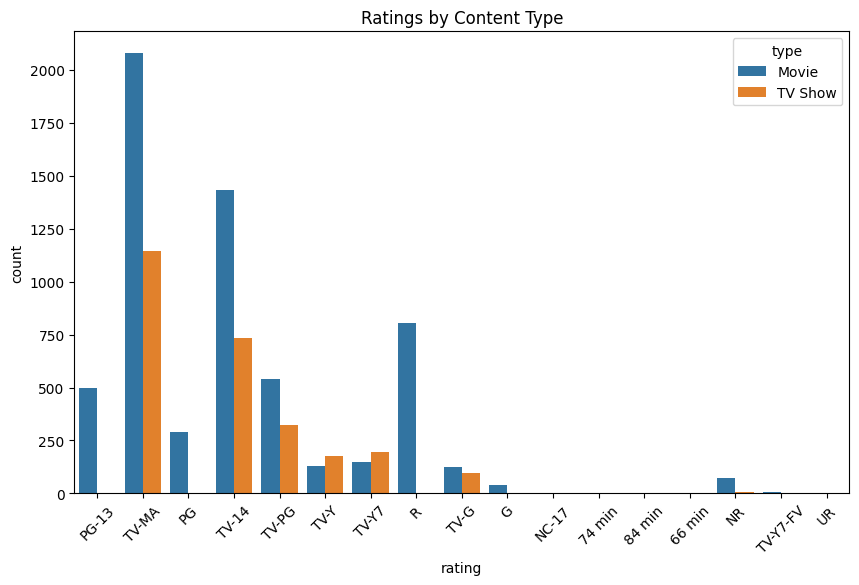

In [117]:
# Rating by Content Type
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="rating", hue="type")
plt.xticks(rotation=45)
plt.title("Ratings by Content Type")
plt.show()

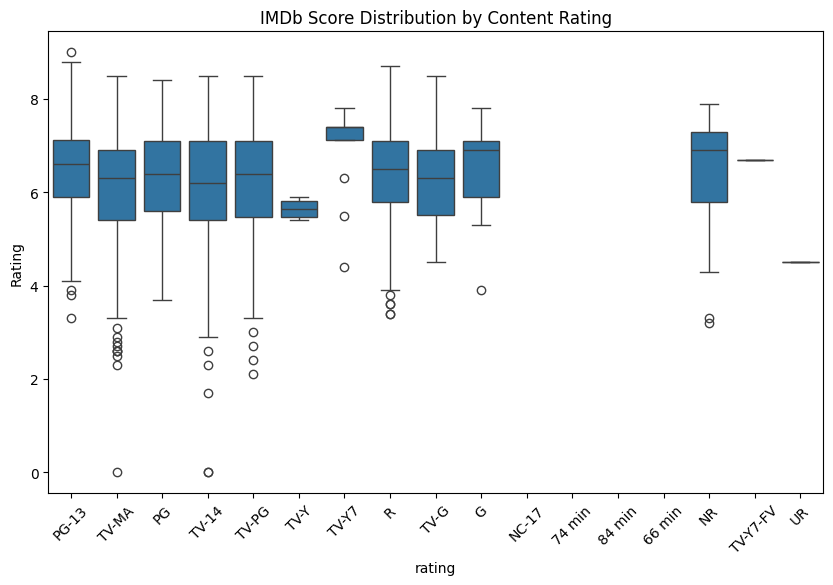

In [118]:
# IMDb Rating vs Content Rating
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="rating", y="Rating")
plt.xticks(rotation=45)
plt.title("IMDb Score Distribution by Content Rating")
plt.show()

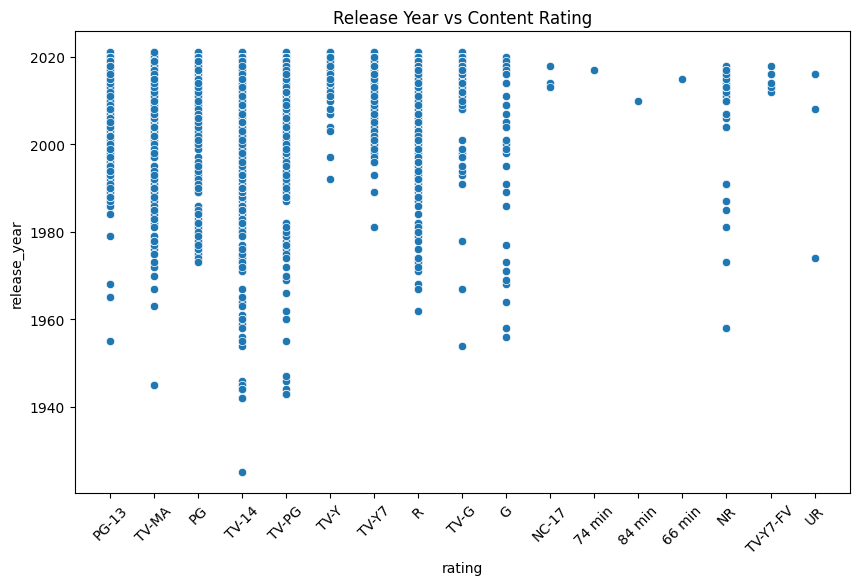

In [119]:
# Release Year vs Rating 
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="rating", y="release_year")
plt.xticks(rotation=45)
plt.title("Release Year vs Content Rating")
plt.show()

### Summary
The dataset contains thousands of Netflix titles with features describing content characteristics such as release year, duration, and genre. The target variable, content rating, is imbalanced with ratings such as TV-MA and TV-14 appearing most frequently. Several of the main features contain several features contain a significant number of missing values which will require preprocessing. Initial visualizations show that rating distributions differ between movies and television shows, suggesting that content type may be an important predictor.

### Feature Engineering

In [120]:
# Create description length feature
df["description_length"] = df["description"].astype(str).apply(len)

Feature description_length counts the number of characters in the content description. It helps because longer descriptions may indicate more complex plots or mature themes that require more detailed summaries. The domain justification is that streaming platforms often provide longer descriptions for complex or mature content aimed at adult audiences.

In [121]:
# Create Genre Count Feature
df["genre_count"] = df["listed_in"].astype(str).apply(lambda x: len(x.split(",")))

Feature genre_count counts how many genres are assigned to a title. It helps because titles with multiple genres may involve more complex themes or content types that influence rating classification. The domain justification is that ratings are often influenced by combinations of genre elements such as violence, horror, or adult themes.

In [122]:
# Create Cast Size Feature
df["cast_count"] = df["cast"].str.split(',').str.len().fillna(0)

Feature cast_count counts the number of actors listed in the cast field. This helps because large productions often have larger casts and may correlate with higher-budget content that targets specific audiences. The domain justification is that production scale and cast size can indirectly reflect content type and target audience.

### NLP Feature Engineering

To incorporate instructor feedback regarding natural language processing, text-based features were created from the description field. Rather than using only the length of the description, a TF-IDF (Term Frequency–Inverse Document Frequency) representation was generated to capture the most important keywords associated with each title.

TF-IDF highlights words that appear frequently in a description but less frequently across all descriptions. This allows the model to detect important thematic signals such as violence, crime, family themes, or other content indicators that may influence a title's rating.

This approach improves the model by capturing information from the text data rather than relying only on numeric metadata features.

In [123]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Replace missing descriptions
df["description"] = df["description"].fillna("")

# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=100,
    stop_words="english"
)

tfidf_features = tfidf.fit_transform(df["description"])

# Convert to dataframe
tfidf_df = pd.DataFrame(
    tfidf_features.toarray(),
    columns=tfidf.get_feature_names_out()
)

# Reset indexes to merge safely
df = df.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)

# Merge TF-IDF features into dataset
df = pd.concat([df, tfidf_df], axis=1)

print("TF-IDF features added:", tfidf_df.shape)

TF-IDF features added: (8860, 100)


### Keyword Feature Engineering

To capture signals of mature content from descriptions, keyword-based features were created. Certain words such as "crime", "war", "violence", and "murder" often appear in descriptions of content intended for mature audiences. A feature was created to count how many of these keywords appear in each title description.

This feature provides a direct indicator of potentially mature themes, which may improve the model's ability to distinguish between rating categories such as TV-MA, TV-14, or PG.

In [124]:
mature_keywords = [
    "crime","murder","kill","war","violence",
    "drug","gang","blood","prison","terror"
]

def keyword_count(text):
    text = str(text).lower()
    count = 0
    for word in mature_keywords:
        if word in text:
            count += 1
    return count

df["mature_keyword_count"] = df["description"].apply(keyword_count)

df["mature_keyword_count"].head()

0    0
1    0
2    3
3    0
4    0
Name: mature_keyword_count, dtype: int64

### Updated Feature List

In [125]:
df = df.rename(columns={"Rating": "imdb_rating"})

features = [
    "release_year",
    "description_length",
    "genre_count",
    "cast_count",
    "mature_keyword_count",
    "country_count"
]

### Clustering Exploration

In addition to supervised classification models, clustering was explored as an unsupervised learning technique to identify natural groupings of Netflix titles. Because content ratings represent categories that may emerge from combinations of features such as genre, description keywords, and production characteristics, clustering can reveal whether titles naturally group into rating-related segments.

K-Means clustering was applied using the engineered numeric features. The resulting clusters can help identify patterns in the data and may also serve as additional features for supervised models.

In [126]:
from sklearn.cluster import KMeans
X = df.select_dtypes(include=["number"]).copy()
X = X.fillna(X.mean())
# Use scaled features for clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X)

df["cluster"] = clusters

df["cluster"].value_counts()

cluster
3    5674
2    1535
0    1278
1     335
4      38
Name: count, dtype: int64

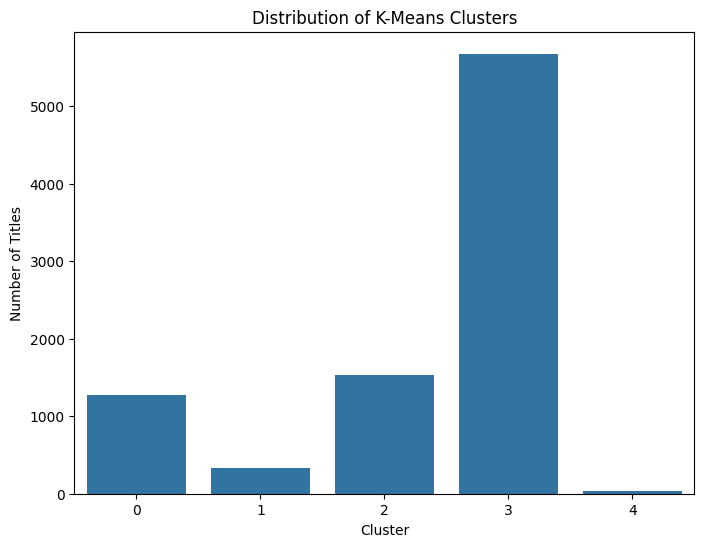

In [127]:
plt.figure(figsize=(8,6))
sns.countplot(x=df["cluster"])
plt.title("Distribution of K-Means Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Titles")
plt.show()

The results from K-means clustering show that Netflix titles are grouped into five clusters based on similarities in their features. The distribution of titles across clusters is uneven, with Cluster 1 containing the largest number of titles (over 4,000), while Cluster 4 contains very few titles. This suggests that most Netflix content shares a common set of characteristics that place it into a dominant group, while only a small number of titles have unique feature combinations that separate them into smaller clusters.

The smaller clusters may represent more specialized types of content, such as niche genres, highly rated productions, or titles with uncommon combinations of attributes. In contrast, the larger clusters likely represent more typical Netflix titles that share similar ratings, genres, or production patterns. Although these clusters do not directly correspond to rating categories, they reveal underlying patterns in the dataset that help group content with similar characteristics.

### Prepare Data for Modeling 

In [128]:
# Select features and target variable
features = [
    "release_year",
    "description_length",
    "genre_count",
    "cast_count"
]

# Remove rare ratings and keep those that appear at least 20 times
df = df[df["rating"].groupby(df["rating"]).transform("count") >= 20]

df_model = df.copy()
X = df_model[features].fillna(0)
y = df["rating"]

# Handle missing values
X = X.fillna(X.mean())

# Encode target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [129]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

During preprocessing, several rating categories appeared only once in the dataset. Since stratified train/test splitting requires at least two samples per class, rare ratings were removed from the dataset. This step helps ensure stable model training and prevents errors during the stratified split. In addition, the dataset was split into training and testing sets using an 80/20 ratio. Stratified sampling was used for the class of the rating variable. Missing values in numeric features were handled using mean imputation. Feature scaling was applied using StandardScaler to normalize the range of input variables before training the models.

### ML Models

In [130]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model1 = LogisticRegression(
    max_iter=1000,
    solver='lbfgs'
)
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

Accuracy: 0.39649321266968324
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00        16
           2       0.00      0.00      0.00        58
           3       0.00      0.00      0.00       100
           4       0.26      0.15      0.19       162
           5       0.33      0.20      0.25       433
           6       0.00      0.00      0.00        44
           7       0.42      0.92      0.57       645
           8       0.00      0.00      0.00       173
           9       0.00      0.00      0.00        61
          10       0.00      0.00      0.00        68

    accuracy                           0.40      1768
   macro avg       0.09      0.11      0.09      1768
weighted avg       0.26      0.40      0.29      1768



c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

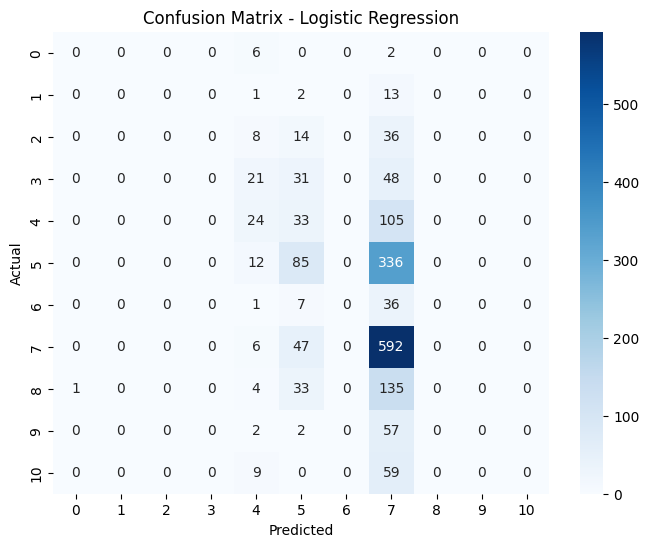

In [131]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [132]:
# Random Forest 
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Accuracy: 0.40328054298642535
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00        16
           2       0.08      0.02      0.03        58
           3       0.29      0.18      0.22       100
           4       0.28      0.27      0.27       162
           5       0.36      0.31      0.33       433
           6       0.33      0.02      0.04        44
           7       0.46      0.76      0.57       645
           8       0.27      0.05      0.08       173
           9       0.26      0.23      0.24        61
          10       0.35      0.10      0.16        68

    accuracy                           0.40      1768
   macro avg       0.24      0.18      0.18      1768
weighted avg       0.36      0.40      0.35      1768



c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### Random Forest Hyperparameter Optimization

To improve model performance, hyperparameter tuning was conducted using GridSearchCV. Multiple combinations of parameters such as the number of trees, maximum tree depth, and minimum samples per split were tested. The goal was to identify a configuration that improves predictive performance while reducing overfitting.

The optimized model was then compared against the baseline Random Forest and Logistic Regression models.

In [133]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

y_pred_rf_opt = best_rf.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_rf_opt))
print(classification_report(y_test, y_pred_rf_opt))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Optimized Accuracy: 0.4123303167420814
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00        16
           2       0.11      0.02      0.03        58
           3       0.27      0.19      0.22       100
           4       0.26      0.25      0.26       162
           5       0.38      0.32      0.35       433
           6       1.00      0.02      0.04        44
           7       0.47      0.78      0.58       645
           8       0.29      0.05      0.08       173
           9       0.28      0.20      0.23        61
          10       0.37      0.10      0.16        68

    accuracy                           0.41      1768
   macro avg       0.31      0.17      0.18      1768
weighted avg       0.38      0.41      0.36      1768



c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

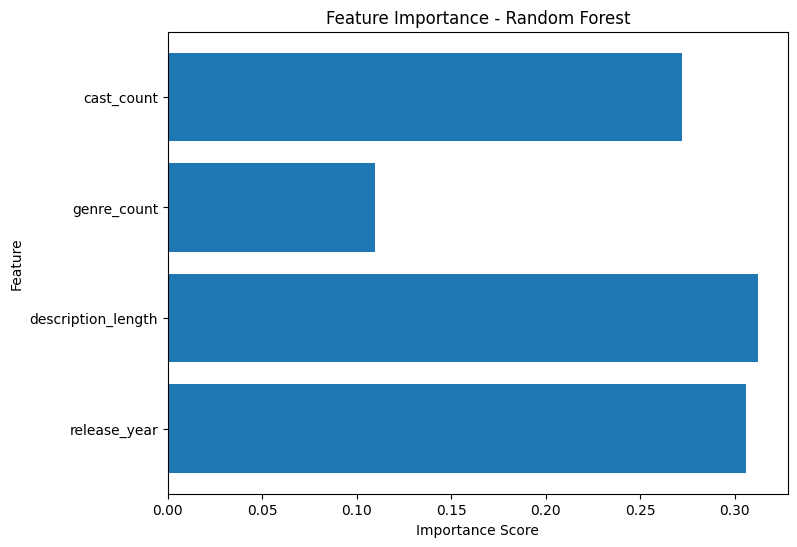

In [134]:
importances = best_rf.feature_importances_

feature_names = features

plt.figure(figsize=(8,6))
plt.barh(feature_names, importances)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

The feature importance results from the Random Forest model show that release year is the most influential feature, followed by cast count** and description length. This suggests that when a title was released and aspects related to production play a larger role in the model’s predictions. In contrast, rating and genre count contribute less to the model, indicating they provide less predictive information compared to the other variables.

### Predicted vs Actual Example Table

In [135]:
import numpy as np

results = pd.DataFrame({
    "Actual": le.inverse_transform(np.array(y_test)),
    "Predicted": le.inverse_transform(np.array(y_pred2))
})

results.head(10)

,Actual,Predicted
0,TV-MA,TV-MA
1,PG,R
2,TV-MA,TV-MA
3,TV-MA,TV-MA
4,TV-MA,TV-MA
5,TV-14,TV-MA
6,TV-MA,TV-14
7,TV-Y7,TV-Y7
8,TV-14,TV-14
9,TV-MA,TV-MA


The results compare the actual ratings with the ratings predicted by the model using a Random Forest. Most of the predictions match the true ratings, indicating that the model is generally effective at identifying patterns in the data. However, a few misclassifications occur, such as predicting R instead of PG or TV-MA instead of TV-14, showing that some ratings have overlapping characteristics that make them harder for the model to distinguish. Overall, the results demonstrate reasonable predictive performance with minor classification errors.


### Update Comparison Table

In [136]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="weighted"),
        recall_score(y_true, y_pred, average="weighted"),
        f1_score(y_true, y_pred, average="weighted")
    ]

log_metrics = get_metrics(y_test, y_pred1)
rf_metrics = get_metrics(y_test, y_pred2)
rf_opt_metrics = get_metrics(y_test, y_pred_rf_opt)

c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [137]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest (Baseline)",
        "Random Forest (Optimized)"
    ],

    "Accuracy": [
        log_metrics[0],
        rf_metrics[0],
        rf_opt_metrics[0]
    ],

    "Precision (Weighted)": [
        log_metrics[1],
        rf_metrics[1],
        rf_opt_metrics[1]
    ],

    "Recall (Weighted)": [
        log_metrics[2],
        rf_metrics[2],
        rf_opt_metrics[2]
    ],

    "F1 Score (Weighted)": [
        log_metrics[3],
        rf_metrics[3],
        rf_opt_metrics[3]
    ],

    "Key Hyperparameters": [
        "max_iter=1000",
        "n_estimators=100, max_depth=10",
        str(grid_search.best_params_)
    ],

    "Training Time": [
        "Fast",
        "Medium",
        "Medium-Slow"
    ]
})

comparison_df

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted),Key Hyperparameters,Training Time
0,Logistic Regression,0.396493,0.257553,0.396493,0.287060,max_iter=1000,Fast
1,Random Forest (Baseline),0.403281,0.357349,0.403281,0.351538,"n_estimators=100, max_depth=10",Medium
2,Random Forest (Optimized),0.412330,0.382296,0.412330,0.357958,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",Medium-Slow


The results show that the Random Forest (Optimized) model achieved the highest performance overall, with the best accuracy, precision, recall, and F1 score among all tested models. This indicates that introducing hyperparameter tuning improved the model’s ability to capture patterns in the data more effectively than both the baseline Random Forest and Logistic Regression models.

The baseline Random Forest model performed slightly better than Logistic Regression, showing that tree-based methods are better suited for this dataset due to their ability to capture non-linear relationships between features and the target variable. However, the optimized Random Forest outperformed both models across all evaluation metrics, suggesting that tuning parameters such as max_depth and min_samples_split helped improve generalization and reduce overfitting.

Although the optimized model required slightly more training time (Medium-Slow), the performance improvement justifies the additional computational cost. Therefore, the Random Forest (Optimized) model is selected as the final model due to its superior overall predictive performance and balanced evaluation metrics.

### Ethical Analysis

Netflix rating prediction models may be influenced by biases present in the training data. For example, historical content ratings may reflect cultural or regional standards that differ across countries. If certain types of content are overrepresented in the dataset, the model may learn patterns that disproportionately favor those categories. Additionally, measurement bias could occur if features such as description text or genre labels are inconsistent across titles.

Incorrect predictions could impact decision-making processes for content classification or recommendation systems. False positives or false negatives in rating predictions could result in inappropriate content being recommended to certain audiences. For example, if mature content is incorrectly predicted as suitable for younger audiences, it could expose viewers to inappropriate material.

To mitigate these risks, several strategies should be implemented before deployment. These include monitoring model performance across different content categories, regularly retraining the model with updated data, and implementing human review for predictions with low confidence. Bias detection techniques and fairness metrics should also be applied to ensure the model performs consistently across different types of content.

### Business Recommendations

The results of this analysis suggest that features such as genre combinations, description characteristics, and production attributes play an important role in predicting content ratings. Streaming platforms could use these insights to assist in the early classification of new content before official ratings are finalized. This could help content managers identify titles that may require additional review or adjustments to ensure compliance with rating guidelines.

For deployment, the model should be used as a decision-support tool rather than a fully automated system. Predictions with high confidence could assist content reviewers, while uncertain predictions should be flagged for manual review. The model should also be retrained periodically as new titles are added to the platform to maintain accuracy and adapt to evolving content trends.

Stakeholders should also be aware of the model's limitations. Because the model relies on metadata and text descriptions, it may not capture nuanced aspects of content such as tone, visual intensity, or context. As a result, predictions should be interpreted as guidance rather than definitive rating assignments.